<a href="https://colab.research.google.com/github/Pratik0124/Collab/blob/main/Text_Preprocessing_and_feature_Extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk

import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("NLTK resources downloaded successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


NLTK resources downloaded successfully!


[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
data = {
    'text': [

        " Hey I am Pratik Raj "
        "I love machine learning and artificial intelligence!",
        "Machine learning is very interesting.",
        "Artificial intelligence is changing the world.",
        "Python is a great programming language.",
    ]
}

df = pd.DataFrame(data)

print(df)

                                                text
0   Hey I am Pratik Raj I love machine learning a...
1              Machine learning is very interesting.
2     Artificial intelligence is changing the world.
3            Python is a great programming language.


Size check of dataset

In [ ]:
print("Dataset Shape:", df.shape)
print("\nFirst Five Rows:")
print(df.head())

Dataset Shape: (4, 1)

First Five Rows:
                                                text
0   Hey I am Pratik Raj I love machine learning a...
1              Machine learning is very interesting.
2     Artificial intelligence is changing the world.
3            Python is a great programming language.


In [ ]:
df['lowercase_text'] = df['text'].str.lower()

print(df[['text', 'lowercase_text']].head())

                                                text  \
0   Hey I am Pratik Raj I love machine learning a...   
1              Machine learning is very interesting.   
2     Artificial intelligence is changing the world.   
3            Python is a great programming language.   

                                      lowercase_text  
0   hey i am pratik raj i love machine learning a...  
1              machine learning is very interesting.  
2     artificial intelligence is changing the world.  
3            python is a great programming language.  


Remove Punctuation and Special Characters

In [ ]:
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['cleaned_text'] = df['lowercase_text'].apply(clean_text)

print(df[['lowercase_text', 'cleaned_text']].head())

                                      lowercase_text  \
0   hey i am pratik raj i love machine learning a...   
1              machine learning is very interesting.   
2     artificial intelligence is changing the world.   
3            python is a great programming language.   

                                        cleaned_text  
0   hey i am pratik raj i love machine learning a...  
1               machine learning is very interesting  
2      artificial intelligence is changing the world  
3             python is a great programming language  


Divided sentence into words

In [ ]:
df['tokens'] = df['cleaned_text'].apply(lambda text: text.split())

print(df[['cleaned_text', 'tokens']].head())

                                        cleaned_text  \
0   hey i am pratik raj i love machine learning a...   
1               machine learning is very interesting   
2      artificial intelligence is changing the world   
3             python is a great programming language   

                                              tokens  
0  [hey, i, am, pratik, raj, i, love, machine, le...  
1         [machine, learning, is, very, interesting]  
2  [artificial, intelligence, is, changing, the, ...  
3      [python, is, a, great, programming, language]  


Remove Stopwords (common words)

In [ ]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [
        word for word in tokens
        if word not in stop_words
    ]

df['filtered_tokens'] = df['tokens'].apply(remove_stopwords)

print(df[['tokens', 'filtered_tokens']].head())

                                              tokens  \
0  [hey, i, am, pratik, raj, i, love, machine, le...   
1         [machine, learning, is, very, interesting]   
2  [artificial, intelligence, is, changing, the, ...   
3      [python, is, a, great, programming, language]   

                                     filtered_tokens  
0  [hey, pratik, raj, love, machine, learning, ar...  
1                   [machine, learning, interesting]  
2        [artificial, intelligence, changing, world]  
3             [python, great, programming, language]  


Stemming is the process of reducing words to their root-like base forms by removing prefixes or suffixes.

In [ ]:
stemmer = PorterStemmer()

def apply_stemming(tokens):
    return [
        stemmer.stem(word) for word in tokens
    ]

df['stemmed_tokens'] = df['filtered_tokens'].apply(apply_stemming)

print(df[['filtered_tokens', 'stemmed_tokens']].head())

                                     filtered_tokens  \
0  [hey, pratik, raj, love, machine, learning, ar...   
1                   [machine, learning, interesting]   
2        [artificial, intelligence, changing, world]   
3             [python, great, programming, language]   

                                      stemmed_tokens  
0  [hey, pratik, raj, love, machin, learn, artifi...  
1                          [machin, learn, interest]  
2                 [artifici, intellig, chang, world]  
3                  [python, great, program, languag]  


Lemmatization attempts to convert words into their dictionary-based base form.

In [ ]:
lemmatizer = WordNetLemmatizer()
def apply_lemmatization(tokens):
    return [
        lemmatizer.lemmatize(word) for word in tokens
    ]
df['lemmatized_tokens'] = df['filtered_tokens'].apply(
    apply_lemmatization
)
print(df[['filtered_tokens', 'lemmatized_tokens']].head())

                                     filtered_tokens  \
0  [hey, pratik, raj, love, machine, learning, ar...   
1                   [machine, learning, interesting]   
2        [artificial, intelligence, changing, world]   
3             [python, great, programming, language]   

                                   lemmatized_tokens  
0  [hey, pratik, raj, love, machine, learning, ar...  
1                   [machine, learning, interesting]  
2        [artificial, intelligence, changing, world]  
3             [python, great, programming, language]  


**Create Final Preprocessed Text**

In [ ]:
df['processed_text'] = df['lemmatized_tokens'].apply(
    lambda tokens: ' '.join(tokens)
)
print(df[['text', 'processed_text']])

                                                text  \
0   Hey I am Pratik Raj I love machine learning a...   
1              Machine learning is very interesting.   
2     Artificial intelligence is changing the world.   
3            Python is a great programming language.   

                                      processed_text  
0  hey pratik raj love machine learning artificia...  
1                       machine learning interesting  
2             artificial intelligence changing world  
3                  python great programming language  


**Bag of Words (BoW)**

In [ ]:
corpus = df['processed_text']

bow_vectorizer = CountVectorizer()

bow_matrix = bow_vectorizer.fit_transform(corpus)

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=bow_vectorizer.get_feature_names_out()
)
 print("Bag of Words Feature Matrix:")
print(bow_df)

Bag of Words Feature Matrix:
   artificial  changing  great  hey  intelligence  interesting  language  \
0           1         0      0    1             1            0         0   
1           0         0      0    0             0            1         0   
2           1         1      0    0             1            0         0   
3           0         0      1    0             0            0         1   

   learning  love  machine  pratik  programming  python  raj  world  
0         1     1        1       1            0       0    1      0  
1         1     0        1       0            0       0    0      0  
2         0     0        0       0            0       0    0      1  
3         0     0        0       0            1       1    0      0  


**TF-IDF Term Frequency–Inverse Document Frequency.**

In [ ]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(
    df['processed_text']
)
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
print("TF-IDF Feature Matrix:")
print(tfidf_df.round(3))

TF-IDF Feature Matrix:
   artificial  changing  great    hey  intelligence  interesting  language  \
0       0.310     0.000    0.0  0.393         0.310        0.000       0.0   
1       0.000     0.000    0.0  0.000         0.000        0.668       0.0   
2       0.438     0.555    0.0  0.000         0.438        0.000       0.0   
3       0.000     0.000    0.5  0.000         0.000        0.000       0.5   

   learning   love  machine  pratik  programming  python    raj  world  
0     0.310  0.393    0.310   0.393          0.0     0.0  0.393  0.000  
1     0.526  0.000    0.526   0.000          0.0     0.0  0.000  0.000  
2     0.000  0.000    0.000   0.000          0.0     0.0  0.000  0.555  
3     0.000  0.000    0.000   0.000          0.5     0.5  0.000  0.000  


In [ ]:
print("TF-IDF Vocabulary:")
print(tfidf_vectorizer.get_feature_names_out())

TF-IDF Vocabulary:
['artificial' 'changing' 'great' 'hey' 'intelligence' 'interesting'
 'language' 'learning' 'love' 'machine' 'pratik' 'programming' 'python'
 'raj' 'world']


In [ ]:
print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (4, 15)


**N-gram Feature Extraction(Group of Words)**

In [ ]:
ngram_vectorizer = CountVectorizer(
    ngram_range=(1, 2)
)
ngram_matrix = ngram_vectorizer.fit_transform(
    df['processed_text']
)
ngram_df = pd.DataFrame(
    ngram_matrix.toarray(),
    columns=ngram_vectorizer.get_feature_names_out()
)
print("N-gram Feature Matrix:")
print(ngram_df)

N-gram Feature Matrix:
   artificial  artificial intelligence  changing  changing world  great  \
0           1                        1         0               0      0   
1           0                        0         0               0      0   
2           1                        1         1               1      0   
3           0                        0         0               0      1   

   great programming  hey  hey pratik  intelligence  intelligence changing  \
0                  0    1           1             1                      0   
1                  0    0           0             0                      0   
2                  0    0           0             1                      1   
3                  1    0           0             0                      0   

   ...  machine learning  pratik  pratik raj  programming  \
0  ...                 1       1           1            0   
1  ...                 1       0           0            0   
2  ...                 0   

**Compare All Feature Extraction Techniques**

In [ ]:
print("Original Dataset Shape:", df.shape)
print("Bag of Words Shape:", bow_matrix.shape)
print("TF-IDF Shape:", tfidf_matrix.shape)
print("N-gram Shape:", ngram_matrix.shape)

Original Dataset Shape: (4, 8)
Bag of Words Shape: (4, 15)
TF-IDF Shape: (4, 15)
N-gram Shape: (4, 28)


**Visualize Word Frequency(make a bar chart of common words)**

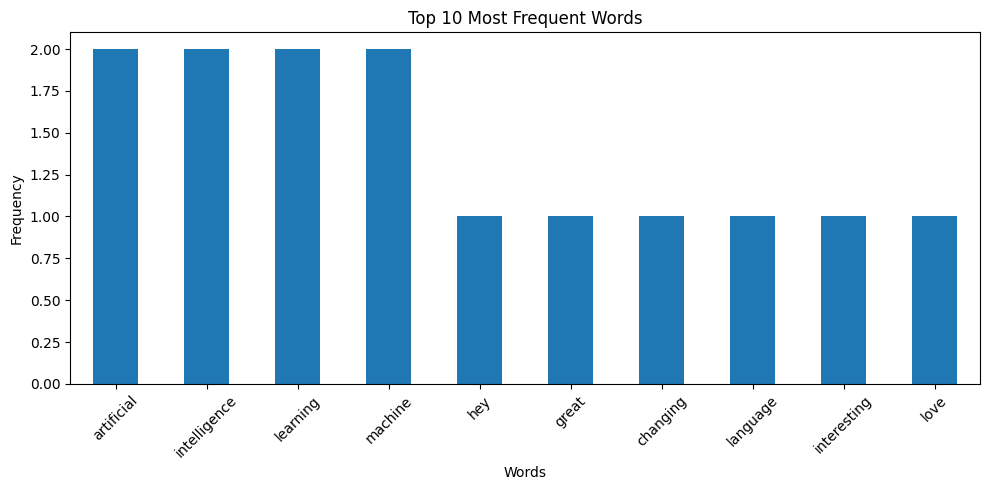

In [ ]:
word_counts = bow_df.sum(axis=0).sort_values(
    ascending=False
)
top_words = word_counts.head(10)
plt.figure(figsize=(10, 5))
top_words.plot(kind='bar')
plt.title("Top 10 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Display Final Results**

In [ ]:
print("Final Preprocessing Results:\n")
print(
    df[
        [
            'text',
            'lowercase_text',
            'cleaned_text',
            'filtered_tokens',
            'stemmed_tokens',
            'processed_text'
        ]
    ].head(10).to_string(index=False)
)

Final Preprocessing Results:

                                                                     text                                                            lowercase_text                                                             cleaned_text                                                       filtered_tokens                                              stemmed_tokens                                               processed_text
 Hey I am Pratik Raj I love machine learning and artificial intelligence!  hey i am pratik raj i love machine learning and artificial intelligence!  hey i am pratik raj i love machine learning and artificial intelligence [hey, pratik, raj, love, machine, learning, artificial, intelligence] [hey, pratik, raj, love, machin, learn, artifici, intellig] hey pratik raj love machine learning artificial intelligence
                                    Machine learning is very interesting.                                     machine learning is very interesting